# Week 4: 베이지안 통계와 Stan 기초

## 학습 목표
베이지안 관점(사전/사후 확률) 이해 및 Stan 기초.

## 이론적 배경 (Mathematical Background)

Bayes' Theorem:  
$$ P(\theta | D) = \frac{P(D | \theta) P(\theta)}{P(D)} $$  
Where:  
- $P(\theta | D)$: Posterior (사후 확률)
- $P(D | \theta)$: Likelihood (우도)
- $P(\theta)$: Prior (사전 확률)
- $P(D)$: Evidence / Marginal Likelihood (증거 / 주변 우도)

## 데이터 시뮬레이션 (Data Simulation)
Python을 사용하여 가상의 데이터를 생성합니다.

In [31]:
import numpy as np
from scipy import stats

# 동전 던지기 시뮬레이션 (Bernoulli Trial)
# True Theta (Fair coin = 0.5)
true_theta = 0.5
N = 20
heads = np.random.binomial(n=1, p=true_theta, size=N).sum()
print(f'{N} tosses, {heads} heads')

20 tosses, 9 heads


## 결과 시뮬레이션 및 가시화 (Visualization)
생성된 데이터 또는 분석 결과를 시각화합니다.

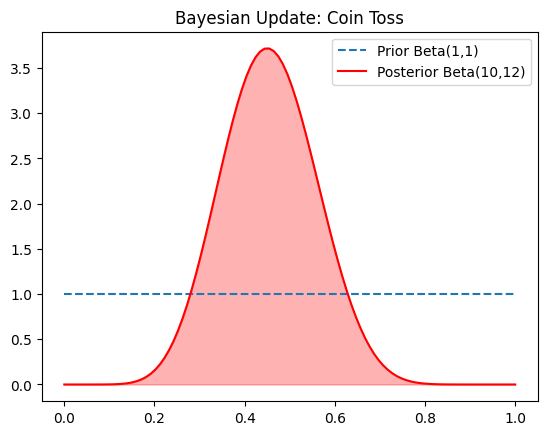

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

x = np.linspace(0, 1, 100)

# Prior: Beta(1, 1) - Uniform
prior = stats.beta.pdf(x, 1, 1)

# Posterior: Beta(1+heads, 1+(N-heads))
posterior = stats.beta.pdf(x, 1 + heads, 1 + (N - heads))

plt.plot(x, prior, label='Prior Beta(1,1)', linestyle='--')
plt.plot(x, posterior, label=f'Posterior Beta({1+heads},{1+(N-heads)})', color='red')
plt.fill_between(x, posterior, alpha=0.3, color='red')
plt.legend()
plt.title('Bayesian Update: Coin Toss')
plt.show()

## Stan/CmdStanPy를 활용한 베이지안 추론 비교 (MCMC Validation)
위에서 계산한 해석적(Analytical) 후광 확률 분포(Posterior)와, Stan을 이용해 MCMC 샘플링으로 얻은 후광 확률 분포가 일치하는지 확인합니다.
이 과정은 MCMC 알고리즘이 올바르게 수렴했는지 검증하는 중요한 단계입니다.

In [33]:
import sys
import subprocess
import platform

print("Checking environment for Bayesian Analysis...")

# 1) Ensure the Python package cmdstanpy is available
try:
    import cmdstanpy
    from cmdstanpy import install_cmdstan
    print(" - 'cmdstanpy' package is available.")
except ImportError:
    print(" - 'cmdstanpy' package not found. Installing via pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "cmdstanpy"])
    # In some environments you may need to restart the kernel after installing.
    import cmdstanpy
    from cmdstanpy import install_cmdstan
    print(" - 'cmdstanpy' package installed successfully.")

# 2) Ensure CmdStan (C++ backend) is installed and discoverable by CmdStanPy
try:
    # cmdstan_path() raises if the path is not set/valid
    path = cmdstanpy.cmdstan_path()
    print(f" - CmdStan found at: {path}")
except Exception:
    print(" - CmdStan not found. Starting installation...")
    current_os = platform.system()

    if current_os == "Windows":
        print("   [Tip] Windows detected. CmdStan requires a C++ toolchain.")
        print("        CmdStanPy can install MinGW automatically (compiler=True).")
        install_cmdstan(compiler=True)
    elif current_os == "Darwin":  # macOS
        print("   [Tip] macOS detected. Install Xcode Command Line Tools: `xcode-select --install`.")
        install_cmdstan()
    else:  # Linux and others
        print("   [Tip] Linux detected. Ensure build tools are installed (e.g., `build-essential`).")
        install_cmdstan()

    print(f" - CmdStan installation completed. CmdStan path: {cmdstanpy.cmdstan_path()}")

Checking environment for Bayesian Analysis...
 - 'cmdstanpy' package is available.
 - CmdStan found at: C:\Users\yongd\.cmdstan\cmdstan-2.37.0


15:14:33 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\bernoulli_beta.stan to exe file C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\bernoulli_beta.exe


Stan model file created.


15:14:41 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\bernoulli_beta.exe
15:14:41 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:14:41 - cmdstanpy - INFO - CmdStan done processing.


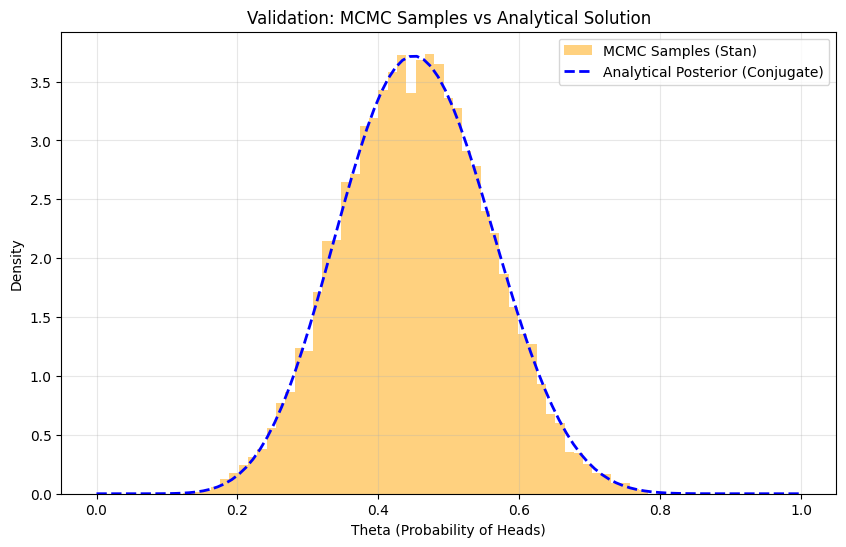

            Mean      MCSE    StdDev       MAD         5%        50%  \
lp__  -15.669600  0.009775  0.721430  0.318216 -17.129700 -15.392700   
theta   0.453126  0.001358  0.103729  0.106974   0.284165   0.452947   

             95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
lp__  -15.160300   6660.53   7400.91     42155.3  1.00032  
theta   0.624427   5827.44   7081.64     36882.5  1.00052  


In [34]:
import os
from cmdstanpy import CmdStanModel

# 1. Stan 모델 정의 (Bernoulli-Beta Model)
# heads 변수는 앞선 셀에서 정의된 '성공 횟수'를 사용하고, N은 '총 시행 횟수'를 사용합니다.
stan_code = """
data {
  int<lower=0> N;
  int<lower=0> heads;
}
parameters {
  real<lower=0, upper=1> theta;
}
model {
  // Prior: conjugate beta prior (uniform if beta(1,1))
  theta ~ beta(1, 1); 
  
  // Likelihood: Binomial distribution
  heads ~ binomial(N, theta);
}
"""

stan_file = 'bernoulli_beta.stan'
with open(stan_file, 'w') as f:
    f.write(stan_code)

print("Stan model file created.")

# 2. 모델 컴파일 및 샘플링
# (Note: CmdStan이 설치되어 있어야 합니다. 처음 실행 시 install_cmdstan() 필요)
# from cmdstanpy import install_cmdstan
# install_cmdstan()

try:
    model = CmdStanModel(stan_file=stan_file)
    
    # 앞선 셀의 데이터 사용 (N, heads)
    stan_data = {'N': N, 'heads': heads}
    
    # MCMC Sampling
    # chains=4, iter_sampling=4000 정도면 충분한 샘플을 얻을 수 있습니다.
    fit = model.sample(data=stan_data, iter_sampling=4000, chains=4, show_progress=True)
    
    # 샘플 추출
    theta_samples = fit.stan_variable('theta')
    
    # 3. 결과 비교 시각화
    plt.figure(figsize=(10, 6))
    
    # MCMC 샘플 히스토그램 (Normalized Density)
    plt.hist(theta_samples, bins=50, density=True, alpha=0.5, color='orange', label='MCMC Samples (Stan)')
    
    # 해석적 후광 분포 (이전 셀의 x, posterior 사용)
    # x: 0~1 사이의 grid points
    # posterior: Beta(1+heads, 1+N-heads) PDF 값
    plt.plot(x, posterior, color='blue', linestyle='--', linewidth=2, label='Analytical Posterior (Conjugate)')
    
    plt.title('Validation: MCMC Samples vs Analytical Solution')
    plt.xlabel('Theta (Probability of Heads)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 요약 통계 출력
    print(fit.summary())

except Exception as e:
    print(f"Error running CmdStanPy: {e}")
    print("CmdStan이 설치되어 있는지, 경로가 올바른지 확인해주세요.")

## cmdstanpy 설치를 위한 코드

In [35]:
import platform
import sys
import subprocess

def install_cmdstan_environment():
    current_os = platform.system()
    print(f"체감 운영체제 (Detected OS): {current_os}")

    # 1. cmdstanpy 파이썬 패키지 설치
    print("Step 1: Installing cmdstanpy python package...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "cmdstanpy"])
        print("cmdstanpy installed successfully.")
    except Exception as e:
        print(f"Failed to install cmdstanpy: {e}")
        return

    # 2. CmdStan (C++ Backend) 설치
    print("Step 2: Installing CmdStan (C++ Backend)...")
    
    try:
        import cmdstanpy
        from cmdstanpy import install_cmdstan
        
        if current_os == "Windows":
            print("[Windows] 윈도우 환경이 감지되었습니다.")
            print("주의: Windows에서는 C++ 컴파일러(RTools 등)가 필요할 수 있습니다.")
            print("일반적으로 install_cmdstan()이 필요한 컴파일러나 바이너리를 자동으로 처리하려고 시도합니다.")
            install_cmdstan()
            
        elif current_os == "Darwin": # macOS
            print("[macOS] 맥 환경이 감지되었습니다.")
            print("주의: 설치 실패 시 터미널에서 'xcode-select --install'을 실행하여 커맨드 라인 툴을 설치해야 할 수 있습니다.")
            install_cmdstan()
            
        else:
            print(f"[{current_os}] 기타 운영체제가 감지되었습니다.")
            install_cmdstan()
            
        print("\nCmdStan 설치 및 설정이 완료되었습니다.")
        
    except Exception as e:
        print(f"\nCmdStan 설치 중 오류 발생: {e}")
        print("공식 문서를 참고하세요: https://mc-stan.org/cmdstanpy/installation.html")

# 필요 시 아래 주석을 해제하고 실행하여 설치를 진행하세요.
# install_cmdstan_environment()

## 빈도주의적 분석 : 동전 던지기 데이터
## (Frequentist Analysis: Coin Toss Data)

앞서 생성한 동전 던지기 시뮬레이션 데이터(`N`회 시행, `heads`회 앞면)를 사용하여 빈도주의 관점에서의 검정을 수행합니다.
(We perform a test from a Frequentist perspective using the coin toss simulation data generated earlier (`N` trials, `heads` heads).)

### 일표본 t-검정 (One-sample t-test)
우리의 데이터는 0(뒷면)과 1(앞면)로 이루어진 베르누이 시행 데이터입니다.
빈도주의 관점에서 **"동전이 공정한가?"** 라는 질문은 다음과 같은 가설 검정으로 바꿀 수 있습니다.
(Our data consists of Bernoulli trials with 0 (tails) and 1 (heads). In the frequentist view, the question **"Is the coin fair?"** translates to the following hypothesis test:)

*   **귀무가설($H_0$):** 동전의 앞면이 나올 확률은 0.5이다. ($\mu = 0.5$)
    *   **Null Hypothesis ($H_0$):** The probability of heads is 0.5.
*   **대립가설($H_1$):** 동전의 앞면이 나올 확률은 0.5가 아니다. ($\mu \neq 0.5$)
    *   **Alternative Hypothesis ($H_1$):** The probability of heads is not 0.5.

데이터가 0과 1로 구성되어 있어도, 표본의 크기($N$)가 충분하다면 t-검정을 통해 평균(비율)에 대한 검정을 수행할 수 있습니다.
(Even with 0/1 data, if the sample size ($N$) is large enough, we can use a t-test to test the mean (proportion).)

In [36]:
from scipy import stats
import numpy as np

print("=== Frequentist Analysis: One-Sample t-Test on Simulation Data ===")

# 1. 시뮬레이션 데이터 복원 (Restore Simulation Data)
# 앞서 우리는 총 N번 중 heads번 앞면이 나온 상황을 시뮬레이션 했습니다.
# 이를 t-test에 넣기 위해 0과 1의 배열로 복원합니다.
sim_data = np.array([1] * heads + [0] * (N - heads))

# 2. 일표본 t-검정 수행 (Population Mean = 0.5 가정)
# Perform One-sample t-test (Assumed Population Mean = 0.5)
# 통계적 유의성 판단 (alpha = 0.05)
t_stat, p_val = stats.ttest_1samp(sim_data, popmean=0.5)

print(f"Total Trials (N): {N}")
print(f"Number of Heads : {heads}")
print(f"Observed Proportion: {heads/N:.2f}")
print("-" * 30)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value    : {p_val:.4f}")

if p_val < 0.05:
    print("\n[결과] p < 0.05: 귀무가설 기각.")
    print("       이 동전은 공정하지 않다고(0.5가 아니라고) 통계적으로 유의미하게 말할 수 있습니다.")
    print("[Result] p < 0.05: Reject Null Hypothesis.")
    print("       We can significantly say this coin is not fair (not 0.5).")
else:
    print("\n[결과] p >= 0.05: 귀무가설 기각 실패.")
    print("       현재 데이터로는 이 동전이 공정하지 않다는 증거가 불충분합니다.")
    print("[Result] p >= 0.05: Fail to Reject Null Hypothesis.")
    print("       There is insufficient evidence to say this coin is unfair.")

=== Frequentist Analysis: One-Sample t-Test on Simulation Data ===
Total Trials (N): 20
Number of Heads : 9
Observed Proportion: 0.45
------------------------------
t-statistic: -0.4381
p-value    : 0.6663

[결과] p >= 0.05: 귀무가설 기각 실패.
       현재 데이터로는 이 동전이 공정하지 않다는 증거가 불충분합니다.
[Result] p >= 0.05: Fail to Reject Null Hypothesis.
       There is insufficient evidence to say this coin is unfair.


In [37]:
print("=== 베이즈 통계에 의한 해석 (Bayesian Interpretation) ===")
print("빈도주의 t-검정은 '동전이 공정한가?'에 대해 기각 여부(Yes/No)만 알려주지만,")
print("앞서 수행한 베이지안 분석(Beta-Binomial)은 '앞면이 나올 확률(theta)' 자체의 분포를 보여줍니다.\n")
print("(Frequentist t-test only gives Yes/No rejection, but Bayesian analysis shows the distribution of theta itself.)\n")

# 베이지안 Posterior 결과 활용
# Posterior Mean (사후 평균) 계산: (alpha + heads) / (alpha + beta + N)
# Prior가 Beta(1,1)이었으므로 alpha=1, beta=1
post_alpha = 1 + heads
post_beta = 1 + (N - heads)
post_mean = post_alpha / (post_alpha + post_beta)

# 95% 신용 구간 (Credible Interval)
lower, upper = stats.beta.ppf([0.025, 0.975], post_alpha, post_beta)

print(f"1. Posterior Mean (추정된 앞면 확률의 기댓값): {post_mean:.3f}")
print(f"2. 95% Credible Interval (신뢰 구간): [{lower:.3f}, {upper:.3f}]")
print("   -> '우리는 95%의 확신으로, 이 동전의 앞면 확률이 {:.3f}와 {:.3f} 사이에 있다고 말할 수 있습니다.'".format(lower, upper))
print("   -> (We are 95% confident that the probability of heads implies between {:.3f} and {:.3f}.)".format(lower, upper))

print("\n3. 공정한 동전(0.5)일 확률 판단:")
# CDF를 이용해 0.5보다 클 확률 계산
prob_gt_05 = 1 - stats.beta.cdf(0.5, post_alpha, post_beta)
print(f"   -> '데이터를 볼 때, 앞면이 나올 확률이 0.5보다 클 확률은 {prob_gt_05*100:.1f}% 입니다.'")
print(f"   -> (Given the data, the probability that theta > 0.5 is {prob_gt_05*100:.1f}%.)")

print("\n4. Kruschke's ROPE (Region of Practical Equivalence) 분석:")
# ROPE 설정: 공정한 동전(0.5) 주위로 실질적으로 차이가 없다고 간주할 범위 (예: 0.45 ~ 0.55)
rope_low = 0.45
rope_high = 0.55

# ROPE 구간 내에 있을 확률 계산 (Posterior Probability inside ROPE)
prob_in_rope = stats.beta.cdf(rope_high, post_alpha, post_beta) - stats.beta.cdf(rope_low, post_alpha, post_beta)

print(f"   -> 설정된 ROPE 구간 (Set ROPE interval): [{rope_low}, {rope_high}]")
print(f"   -> ROPE 내에 있을 확률(이 동전이 실질적으로 공정할 확률): {prob_in_rope*100:.1f}%")
print(f"   -> (Probability inside ROPE (Probability that coin is practically fair): {prob_in_rope*100:.1f}%)")

# 판정
if prob_in_rope > 0.95:
    print("   -> 결론: 동전은 실질적으로 공정합니다. (ROPE 내 확률 > 95%)")
    print("   -> (Conclusion: The coin is practically fair.)")
elif prob_in_rope < 0.05: # 매우 낮다면 공정하지 않음 (이 예제에서는 단순화함)
    print("   -> 결론: 동전은 실질적으로 공정하지 않을 가능성이 높습니다.")
    print("   -> (Conclusion: The coin is likely not fair.)")
else:
    print("   -> 결론: 데이터가 충분하지 않아 공정성에 대해 확단할 수 없습니다. (Undecided)")
    print("   -> (Conclusion: Undecided due to insufficient data.)")

=== 베이즈 통계에 의한 해석 (Bayesian Interpretation) ===
빈도주의 t-검정은 '동전이 공정한가?'에 대해 기각 여부(Yes/No)만 알려주지만,
앞서 수행한 베이지안 분석(Beta-Binomial)은 '앞면이 나올 확률(theta)' 자체의 분포를 보여줍니다.

(Frequentist t-test only gives Yes/No rejection, but Bayesian analysis shows the distribution of theta itself.)

1. Posterior Mean (추정된 앞면 확률의 기댓값): 0.455
2. 95% Credible Interval (신뢰 구간): [0.257, 0.660]
   -> '우리는 95%의 확신으로, 이 동전의 앞면 확률이 0.257와 0.660 사이에 있다고 말할 수 있습니다.'
   -> (We are 95% confident that the probability of heads implies between 0.257 and 0.660.)

3. 공정한 동전(0.5)일 확률 판단:
   -> '데이터를 볼 때, 앞면이 나올 확률이 0.5보다 클 확률은 33.2% 입니다.'
   -> (Given the data, the probability that theta > 0.5 is 33.2%.)

4. Kruschke's ROPE (Region of Practical Equivalence) 분석:
   -> 설정된 ROPE 구간 (Set ROPE interval): [0.45, 0.55]
   -> ROPE 내에 있을 확률(이 동전이 실질적으로 공정할 확률): 32.8%
   -> (Probability inside ROPE (Probability that coin is practically fair): 32.8%)
   -> 결론: 데이터가 충분하지 않아 공정성에 대해 확단할 수 없습니다. (Undecided)
   -> (Conclusion: Undecided due to